In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


I0000 00:00:1782397899.233716  217136 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load dataset
df = pd.read_csv('../data/Parking_Birmingham.csv')

print(df.shape)
df.head()

(35717, 4)


,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48


In [3]:
# Basic preprocessing
df['LastUpdated'] = pd.to_datetime(df['LastUpdated'])
df = df.sort_values(['SystemCodeNumber','LastUpdated'])

# Occupancy rate
df['OccupancyRate'] = df['Occupancy'] / df['Capacity']

# Time features
df['Hour'] = df['LastUpdated'].dt.hour
df['DayOfWeek'] = df['LastUpdated'].dt.dayofweek
df['Month'] = df['LastUpdated'].dt.month
df['Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Lag features
for lag in [1,2,3]:
    df[f'lag_{lag}'] = (
        df.groupby('SystemCodeNumber')['Occupancy']
          .shift(lag)
    )

df = df.dropna().reset_index(drop=True)

print(df.shape)
df.head()


(35627, 12)


,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,Hour,DayOfWeek,Month,Weekend,lag_1,lag_2,lag_3
0,BHMBCCMKT01,577,107,2016-10-04 09:32:46,0.185442,9,1,10,0,80.0,64.0,61.0
1,BHMBCCMKT01,577,150,2016-10-04 09:59:48,0.259965,9,1,10,0,107.0,80.0,64.0
2,BHMBCCMKT01,577,177,2016-10-04 10:26:49,0.306759,10,1,10,0,150.0,107.0,80.0
3,BHMBCCMKT01,577,219,2016-10-04 10:59:48,0.379549,10,1,10,0,177.0,150.0,107.0
4,BHMBCCMKT01,577,247,2016-10-04 11:25:47,0.428076,11,1,10,0,219.0,177.0,150.0


In [4]:
# Encode parking location
le = LabelEncoder()
df['SystemCodeEncoded'] = le.fit_transform(df['SystemCodeNumber'])

features = [
    'Capacity',
    'Hour',
    'DayOfWeek',
    'Month',
    'Weekend',
    'lag_1',
    'lag_2',
    'lag_3',
    'SystemCodeEncoded'
]

target = 'Occupancy'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


## Random Forest (Primary Model)

In [5]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")

print("R²  :", rf_r2)


Random Forest Results
R²  : 0.9965862747554474


In [6]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

importance


,Feature,Importance
5,lag_1,0.948412
1,Hour,0.036141
0,Capacity,0.004410
7,lag_3,0.004242
6,lag_2,0.003535
8,SystemCodeEncoded,0.001997
2,DayOfWeek,0.000660
3,Month,0.000302
4,Weekend,0.000302


## LSTM Comparison Model

In [7]:
series = df[['Occupancy']].copy()

scaler = MinMaxScaler()
scaled = scaler.fit_transform(series)

SEQ_LEN = 12

X_lstm = []
y_lstm = []

for i in range(SEQ_LEN, len(scaled)):
    X_lstm.append(scaled[i-SEQ_LEN:i])
    y_lstm.append(scaled[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

split = int(0.8 * len(X_lstm))

X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]


In [8]:

model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/5


W0000 00:00:1782397902.869667  217305 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782397903.172086  217136 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


  1/401 ━━━━━━━━━━━━━━━━━━━━ 7:25 1s/step - loss: 0.0069

 14/401 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0050 

 28/401 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040

...

354/401 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3828e-04

370/401 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3807e-04

386/401 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3322e-04

401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3121e-04

401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.3121e-04 - val_loss: 0.0025


In [9]:
pred = model.predict(X_test_lstm)

pred_actual = scaler.inverse_transform(pred)
y_actual = scaler.inverse_transform(y_test_lstm)


lstm_r2 = r2_score(y_actual, pred_actual)

print("LSTM Results")

print("R²  :", lstm_r2)


  1/223 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step

 51/223 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

 99/223 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

152/223 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

205/223 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step

223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


LSTM Results
R²  : 0.8814731869224118


In [10]:
results = pd.DataFrame({
    'Model':['Random Forest','LSTM'],

    'R2':[rf_r2,lstm_r2]
})

results


,Model,R2
0,Random Forest,0.996586
1,LSTM,0.881473


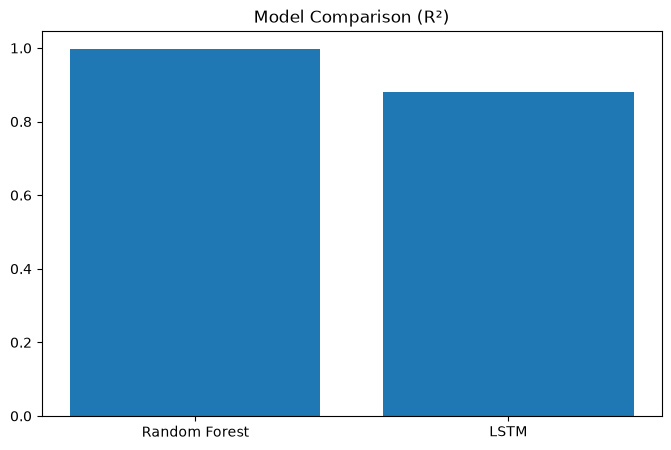

In [11]:
plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['R2'])
plt.title('Model Comparison (R²)')
plt.show()


In [12]:
import joblib

# Save
joblib.dump(rf, '../models/random_forest_parking.pkl')
print("Random Forest saved!")

# Load back (whenever needed)
rf_loaded = joblib.load('../models/random_forest_parking.pkl')

Random Forest saved!


In [13]:
# Save
model.save('../models/lstm_parking.keras')
print("LSTM model saved!")

# Load back
from tensorflow.keras.models import load_model
lstm_loaded = load_model('../models/lstm_parking.keras')

LSTM model saved!


In [14]:
joblib.dump(scaler, '../models/minmax_scaler.pkl')

# Load back
scaler_loaded = joblib.load('../models/minmax_scaler.pkl')

In [15]:
joblib.dump(le, '../models/label_encoder.pkl')

['../models/label_encoder.pkl']